In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
df = pd.read_csv(r"data.csv")
print(df.head())

   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1             0  3

Target column

In [3]:
df["result"] = df["GradeClass"].apply(lambda x:1 if x<=2 else 0)

Drop useless column

In [4]:
df = df.drop("StudentID",axis=1)

EDA(Explorately Data Analysis)

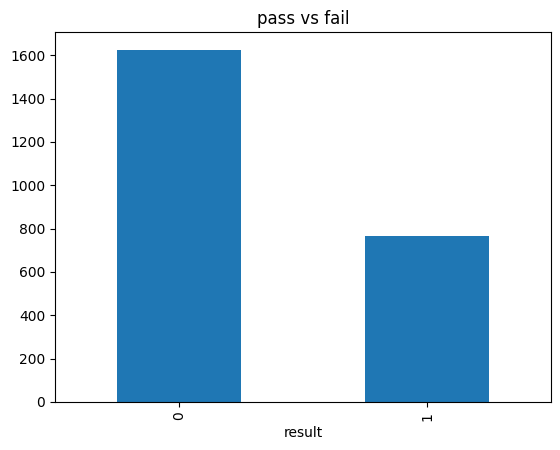

In [11]:
df["result"].value_counts().plot(kind="bar")
plt.title("pass vs fail")
plt.show()

GPA Distribution

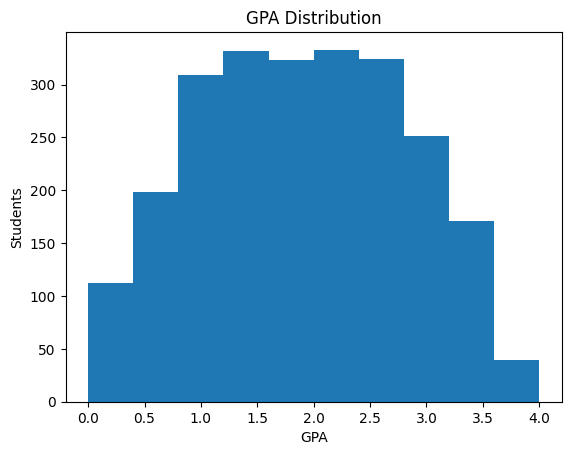

In [12]:
plt.hist(df['GPA'], bins=10)
plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Students")
plt.show()

Study Time Vs GPA

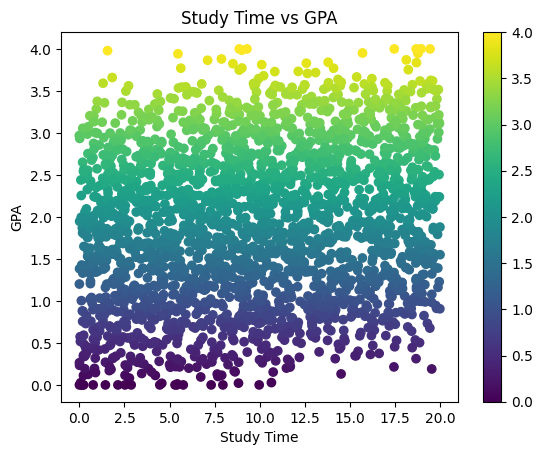

In [43]:
plt.scatter(df['StudyTimeWeekly'], df['GPA'],c=df['GPA'], cmap='viridis')
plt.colorbar()
plt.xlabel("Study Time")
plt.ylabel("GPA")
plt.title("Study Time vs GPA")
plt.show()

Correlation

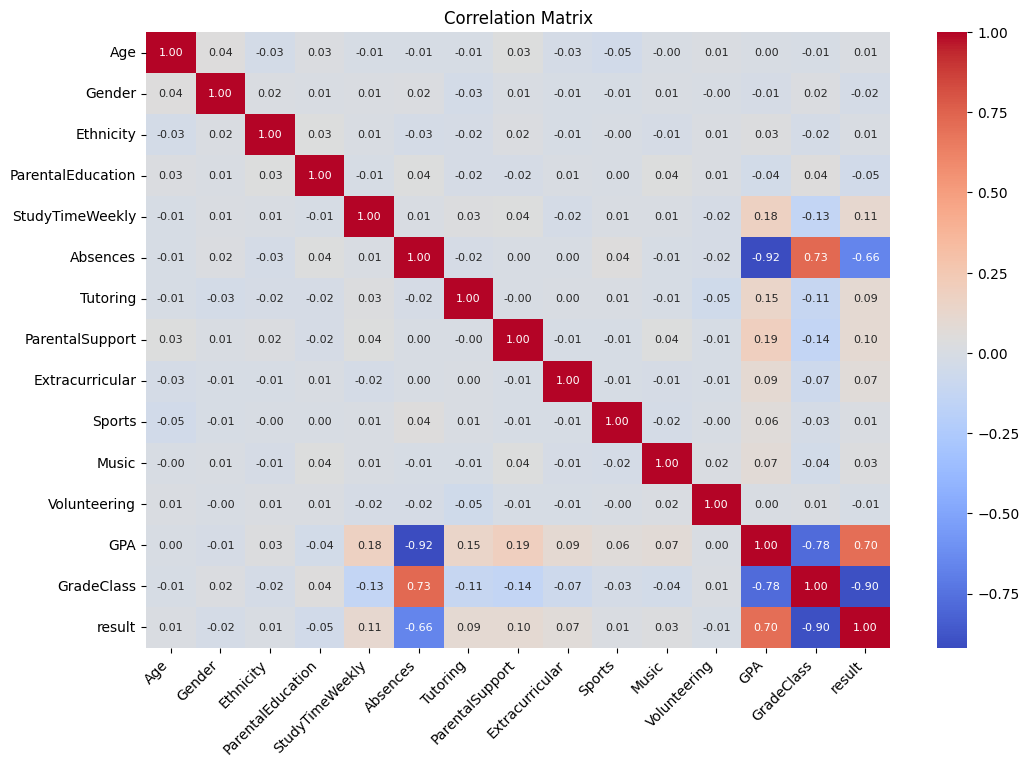

In [21]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            fmt=".2f",
            annot=True,
            cmap="coolwarm",
           annot_kws = {"size":8}
           )
plt.xticks(rotation=45,ha="right")
plt.title("Correlation Matrix")
plt.show()

Features and Target

In [25]:
X = df.drop(["GradeClass","result"],axis=1)
y = df["result"]

Divide data for training and testing

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
# model
log_model = LogisticRegression(max_iter =1000)

#train model
log_model.fit(X_train,y_train)

#predict
y_pred_log = log_model.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9352818371607515

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       318
           1       0.92      0.89      0.90       161

    accuracy                           0.94       479
   macro avg       0.93      0.92      0.93       479
weighted avg       0.93      0.94      0.94       479



Decision Tree Model

In [30]:
from sklearn.tree import DecisionTreeClassifier

#model
tree_model = DecisionTreeClassifier()
#train model
tree_model.fit(X_train,y_train)
#prdiction
y_tree_pred = tree_model.predict(X_test)
#Accuracy
print("Decision Tree Accuracy",accuracy_score(y_tree_pred,y_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Decision Tree Accuracy 0.906054279749478

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       318
           1       0.92      0.89      0.90       161

    accuracy                           0.94       479
   macro avg       0.93      0.92      0.93       479
weighted avg       0.93      0.94      0.94       479



Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

# Model
rf_model = RandomForestClassifier(n_estimators=100)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9498956158663883

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96       318
           1       0.95      0.89      0.92       161

    accuracy                           0.95       479
   macro avg       0.95      0.94      0.94       479
weighted avg       0.95      0.95      0.95       479



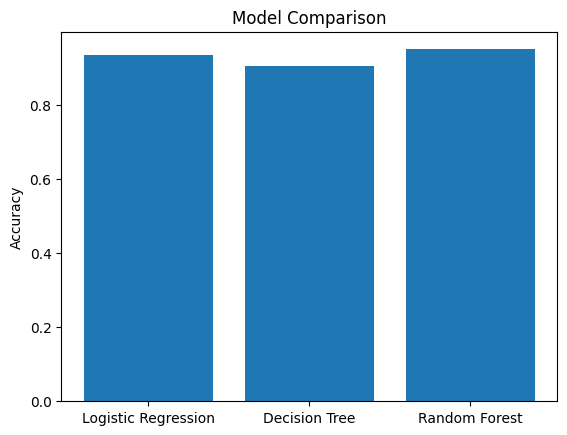

In [33]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_tree_pred),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

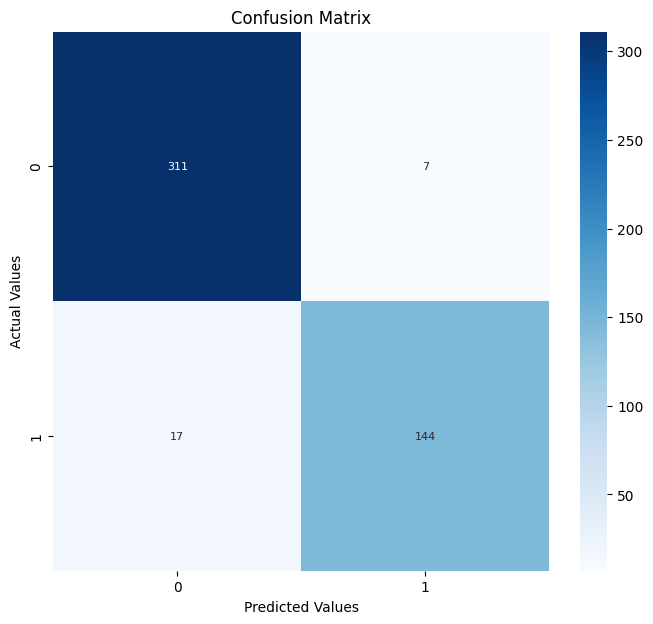

In [35]:
cm = confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(8,7))

sns.heatmap(cm,
            fmt="d",
            annot=True,
            annot_kws = {"size":8},
            cmap="Blues",
            cbar=True)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix")
plt.show()

which feature helps most(useful)

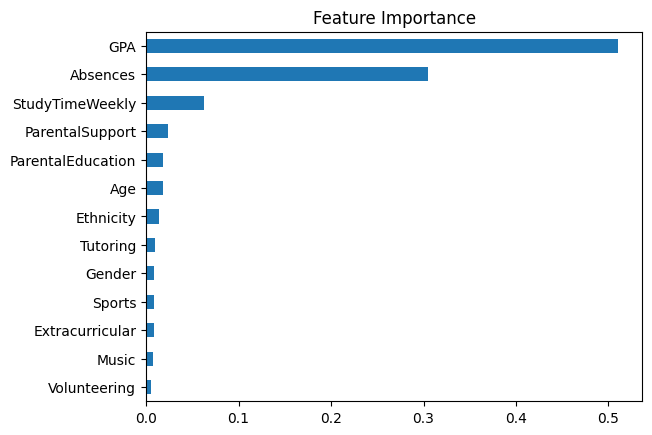

In [45]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()